# SQL-Gen Analysis — Workload Diversity Evaluation

Coherent, paper-facing evaluation of the query generator against hand-crafted and
generated baselines on TPC-DS. Layout mirrors the paper:

| Section | Table / figure | What it answers |
|---|---|---|
| 0 · Load | — | workloads, universes, styler |
| 1 · Structural diversity | **Table 1** | Are the physical plans distinct, broad, and spread out? |
| 2 · Schema diversity | **Table 2** | Do we touch the whole schema? |
| 3 · Quality & overhead | **Table 3** | Valid, and at what cost? |
| 4 · Analysis: exploration & the entropy ceiling | figures | Where feedback helps; why a wider operator vocabulary gets harder to use evenly |

**Headline metric: plan-graph Vendi** (effective number of distinct plans). The
structural table is the thesis; entropy lives in §4 as *analysis*, not a
scoreboard (it rewards narrowness — see the SQLBarber exhibit).

## 0 · Load workloads, universes, styler

In [1]:
import json, glob, math
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


FIGURES_DIR = Path("./results/figures").resolve()

REF       = "tpcds_1200"                              
OURS      = ["gpt_generated_1000_tpcds_tokens_no_feedback", "gpt_generated_1000_tpcds_tokens"]     
BASELINES = ["bootstrapping_lcm_1000_tokens_tpcds",  # alphabetical by display name
"e2etune_1000_tokens_tpcds",
"sql_factory_1000_tokens_tpcds",
"sqlbarber_1000_tokens_tpcds",
"sqlstorm_1000_tokens_tpcds",
]


plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 9, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.5,
})

_files = sorted(glob.glob("results/*.csv"), key=lambda p: Path(p).stat().st_mtime)
df = None
for _p in _files:
    _d = pd.read_csv(_p)
    if "workload" not in _d.columns:
        continue  # not a per-workload results file (e.g. Table 1's scale-by-N csv)
    _d = _d.set_index("workload")
    df = _d if df is None else _d.combine_first(df)


ROWS = [REF] + BASELINES + OURS   # reference first, baselines (A-Z), ours last
missing = [w for w in ROWS if w not in df.index]
assert not missing, f"missing workloads: {missing}"

# --- fixed universes (same denominator for every workload) -------------------
_ops = pd.read_csv(Path("../resources/operators_ground_truth.csv"))
U_OP = int((_ops["category"].astype(str).str.lower() != "dml").sum())   # non-DML operators
print(f"operator universe |U| = {U_OP} (non-DML operators)")

WORKLOAD_ROOTS = [Path("../../Workloads"), Path("/mnt/primary/Main/Workloads")]
def find_report(w):
    for r in WORKLOAD_ROOTS:
        p = Path(r) / w / "generation_report.json"
        if p.exists():
            return json.loads(p.read_text(encoding="utf-8"))
    return None
reports = {w: r for w in ROWS if (r := find_report(w)) is not None}

# --- pretty names + colours + styler -----------------------------------------
PRETTY = {"tpcds_1200":"TPC-DS (1000)", "gpt_generated_1000_tpcds_tokens":"DiverSQL (W/ Feedback)", "gpt_generated_1000_tpcds_tokens_no_feedback":"DiverSQL (W/O Feedback)",
          "sqlstorm_1000_tokens_tpcds":"SQLStorm", "sqlbarber_1000_tokens_tpcds":"SQLBarber",
          "sql_factory_1000_tokens_tpcds":"SQL-Factory", "e2etune_1000_tokens_tpcds":"E2ETune",
          "bootstrapping_lcm_1000_tokens_tpcds":"Bootstrapping-LCM"}

COL = {w: "#b8b8b8" for w in ROWS}
for w in OURS: COL[w] = "#ea580c"
COL[REF] = "#111111"
_INV = {v:k for k,v in PRETTY.items()}

def show(tbl, fmt="{:.3f}", **kw):
    disp = tbl.rename(index=PRETTY)
    def hl(row):
        key = _INV.get(row.name, row.name)
        if key == REF:  return ["background-color:#f3f4f6;font-style:italic"]*len(row)
        if key in OURS: return ["background-color:#fff1e6;font-weight:600"]*len(row)
        return [""]*len(row)
    sty = disp.style.apply(hl, axis=1)
    return sty.format(fmt, **kw) if fmt else sty


operator universe |U| = 57 (non-DML operators)


## 1 · Structural diversity  —  **Table 1**

Distinctness, breadth and spread of the compiled physical plans. **Plan-graph
Vendi** (rightmost) is the headline: the effective number of structurally distinct
plans. The others corroborate it — *operator coverage* (breadth of the operator
space), *unique plan-graph ratio* (share of non-duplicate plans), and *mean NN
distance* (spread, so a high Vendi can't be a few outliers).

Vendi is reported under two kernels. **Vendi (κ)** is the hand-built plan-graph kernel
(weighted Jaccard over operator / edge / 3-gram counts). **Vendi (cosine)** is a
robustness check with a learned kernel: cosine similarity between GIN plan embeddings
from the QPP evaluation's encoder, trained once on the pooled plans of all 8 workloads
(vocabulary taken from those plans) and standardised on the pooled set. It is computed in
[`plan_vendi_gin_cosine.ipynb`](plan_vendi_gin_cosine.ipynb) and read here from its cached CSV.

In [2]:
table1 = pd.DataFrame({
    "Operator types":          df.loc[ROWS, "n_operator_types_observed"],
    "Operator cov. (K/|U|)":   df.loc[ROWS, "n_operator_types_observed"] / U_OP,
    "Unique plan-graph ratio": df.loc[ROWS, "plan_graph_uniqueness_ratio"],
    "Mean NN distance":        df.loc[ROWS, "mean_nearest_neighbour_distance"],
    "Plan-graph Vendi":        df.loc[ROWS, "plan_graph_vendi_score"],
}, index=ROWS).astype(float)

# learned-kernel Vendi: GIN embeddings (pooled vocab, standardised) + cosine -- see plan_vendi_gin_cosine.ipynb
_GIN_CSV = Path("results/gin_vendi/plan_vendi_gin_cosine.csv")
assert _GIN_CSV.exists(), f"{_GIN_CSV} missing -- run plan_vendi_gin_cosine.ipynb first"
_gin = pd.read_csv(_GIN_CSV, index_col=0)
table1["Vendi (cosine)"] = _gin.loc[ROWS, "GIN cosine, pooled vocab, std."].astype(float)

show(table1, None).format({
    "Operator types": "{:.0f}", "Operator cov. (K/|U|)": "{:.2f}",
    "Unique plan-graph ratio": "{:.3f}", "Mean NN distance": "{:.3f}",
    "Plan-graph Vendi": "{:.1f}", "Vendi (cosine)": "{:.1f}",
})

,Operator types,Operator cov. (K/|U|),Unique plan-graph ratio,Mean NN distance,Plan-graph Vendi,Vendi (cosine)
TPC-DS (1000),28,0.49,0.075,0.000,22.7,7.7
Bootstrapping-LCM,28,0.49,0.916,0.138,19.0,7.0
E2ETune,30,0.53,0.976,0.245,55.3,11.3
SQL-Factory,30,0.53,0.965,0.219,52.4,9.6
SQLBarber,26,0.46,0.108,0.002,16.4,3.4
SQLStorm,35,0.61,0.790,0.270,77.6,9.9
DiverSQL (W/O Feedback),37,0.65,1.000,0.325,87.1,13.0
DiverSQL (W/ Feedback),37,0.65,1.000,0.374,106.1,13.2


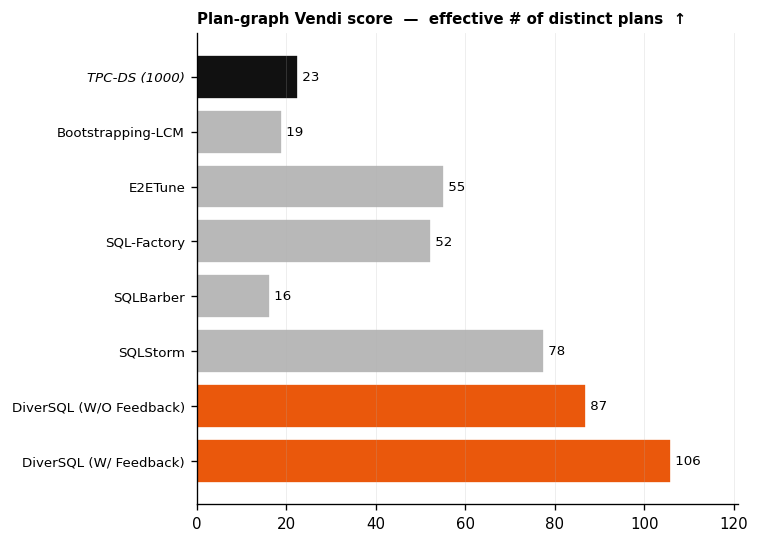

In [3]:
# headline figure: plan-graph Vendi
fig, ax = plt.subplots(figsize=(6.4, 0.5*len(ROWS)+0.6))
vals = table1["Plan-graph Vendi"]
ax.barh(range(len(ROWS)), vals.values, color=[COL[w] for w in ROWS], edgecolor="white")
for i, v in enumerate(vals.values):
    ax.text(v, i, f" {v:,.0f}", va="center", fontsize=8)
ax.set_yticks(range(len(ROWS))); ax.set_yticklabels([PRETTY[w] for w in ROWS], fontsize=8)
ax.get_yticklabels()[0].set_fontstyle("italic")
ax.invert_yaxis(); ax.margins(x=0.14); ax.grid(axis="y", visible=False)
ax.set_title("Plan-graph Vendi score  —  effective # of distinct plans  ↑",
             loc="left", fontsize=9, fontweight="bold")
plt.tight_layout(); plt.show()

## 2 · Schema diversity  —  **Table 2**

Do the queries touch the whole schema, and are table combinations varied?
*Coverage* is the fraction of tables / columns / FK-edges referenced anywhere;
*unique table-set ratio* is the share of distinct table combinations. All in
`[0,1]`, higher is better. (Usage **entropy** is deferred to §4.)

In [4]:
table2 = pd.DataFrame({
    "Table cov.":              df.loc[ROWS, "table_coverage"],
    "Column cov.":             df.loc[ROWS, "column_coverage"],
    "Join-edge cov.":          df.loc[ROWS, "join_edge_coverage"],
    "Unique table-set ratio":  df.loc[ROWS, "unique_table_set_ratio"],
}, index=ROWS).astype(float)

show(table2)

,Table cov.,Column cov.,Join-edge cov.,Unique table-set ratio
TPC-DS (1000),1.000,0.614,0.683,0.054
Bootstrapping-LCM,1.000,0.800,1.000,0.394
E2ETune,1.000,0.904,1.000,0.882
SQL-Factory,1.000,0.805,0.988,0.382
SQLBarber,1.000,0.593,0.963,0.122
SQLStorm,1.000,0.744,0.768,0.397
DiverSQL (W/O Feedback),1.000,0.974,1.000,0.948
DiverSQL (W/ Feedback),1.000,0.979,1.000,0.932


## 3 · Quality & overhead  —  **Table 3**

*Validity* = queries that parse **and** execute / queries requested (baselines are
distributed pre-validated, so they read ~100%). Overhead (wall-clock, throughput)
is only defined for generators we ran end-to-end; external baselines show —.

**Tokens / query** = `total_tokens / query_count` (the delivered workload size,
1,000 for every generator here). We report this rather than a per-attempt cost,
because our pipeline is *designed* to generate and discard candidates as part of
its diversity-forcing mechanism (plan-signature caps, near-duplicate rejection) —
amortizing total generation cost over the queries actually delivered is the fair
comparison, not an attempt-level number that would need explaining away for an
approach that expects to throw work away on purpose.

**Unique plans / min** and **Vendi / min** divide the Table 1 diversity numbers
(distinct plan graphs; effective # of distinct plans) by generation wall-clock, so
they read as *structural diversity delivered per minute* — a throughput that
credits a generator only for plans that are actually different, not for raw query
count.

In [5]:
def _get(w, col):
    # tolerant: missing column (older CSVs) or missing value -> NaN, never an error
    v = df.loc[w].get(col, np.nan) if col in df.columns else np.nan
    return float(v) if pd.notna(v) else np.nan

table3 = pd.DataFrame({
    "Validity %":      df.loc[ROWS, "ok"] / df.loc[ROWS, "query_count"] * 100,
    "Tokens / query":  [ _get(w, "gen_tokens_per_query") for w in ROWS ],   # blank for pre-token CSVs
    # token breakdown (total = input + output; output includes reasoning tokens)
    "Input tok / query":     [ _get(w, "gen_input_tokens")     / _get(w, "query_count") for w in ROWS ],
    "Output tok / query":    [ _get(w, "gen_output_tokens")    / _get(w, "query_count") for w in ROWS ],
    "Reasoning tok / query": [ _get(w, "gen_reasoning_tokens") / _get(w, "query_count") for w in ROWS ],
    "LLM calls / query":     [ _get(w, "gen_llm_calls")        / _get(w, "query_count") for w in ROWS ],
    "Gen. time (min)": [ _get(w, "gen_duration_s")/60.0 for w in ROWS ],
    "Sec / query":     [ _get(w, "gen_seconds_per_query") for w in ROWS ],
    "Queries / min":   [ _get(w, "gen_queries_per_min") for w in ROWS ],
    # diversity delivered per unit of wall-clock: distinct plans (and effective
    # # of distinct plans) produced per minute of generation
    "Unique plans / min": [ _get(w, "unique_plan_graph_count") / (_get(w, "gen_duration_s")/60.0) for w in ROWS ],
    "Vendi / min":        [ _get(w, "plan_graph_vendi_score")   / (_get(w, "gen_duration_s")/60.0) for w in ROWS ],
}, index=ROWS)

show(table3, None).format({
    "Validity %": "{:.1f}", "Gen. time (min)": "{:.1f}", "Queries / min": "{:.2f}",
    "Sec / query": "{:.1f}", "Tokens / query": "{:,.0f}",
    "Unique plans / min": "{:.1f}", "Vendi / min": "{:.2f}",
    "Input tok / query": "{:,.0f}", "Output tok / query": "{:,.0f}",
    "Reasoning tok / query": "{:,.0f}", "LLM calls / query": "{:.2f}",
}, na_rep="—")

,Validity %,Tokens / query,Input tok / query,Output tok / query,Reasoning tok / query,LLM calls / query,Gen. time (min),Sec / query,Queries / min,Unique plans / min,Vendi / min
TPC-DS (1000),100.0,—,—,—,—,—,—,—,—,—,—
Bootstrapping-LCM,100.0,"12,734","1,962","10,773","10,082",1.50,456.0,27.4,2.19,2.0,0.04
E2ETune,100.0,"7,985","1,853","6,132","5,458",1.40,239.5,14.4,4.17,4.1,0.23
SQL-Factory,100.0,"3,198",341,"2,856","2,331",0.34,332.0,19.9,3.01,2.9,0.16
SQLBarber,100.0,"1,072",283,788,704,0.45,193.8,11.6,5.16,0.6,0.08
SQLStorm,100.0,"26,329","8,340","17,989","14,466",3.68,899.9,54.0,1.11,0.9,0.09
DiverSQL (W/O Feedback),100.0,"8,432","3,789","4,643","3,244",1.64,63.2,3.8,15.83,15.8,1.38
DiverSQL (W/ Feedback),100.0,"14,876","6,068","8,808","6,068",2.59,130.7,7.8,7.65,7.7,0.81


## 4 · Analysis: exploration & the entropy ceiling

This section is the paper's *characterisation*, not a scoreboard. Two linked points.

### 4a · Entropy vs. the operator vocabulary size — a discussion point, not a scoreboard
Shannon **entropy** `H = -sum(p log p)` over operator-type usage is the intuitive
number: it's "how unpredictable is the next operator", in nats, with no
normalisation to explain. The usual next step is to divide by `ln(K_obs)` to get
**evenness** `H / ln K` — but that ratio is a second concept a reader has to hold
in their head, and it *penalises* a generator for discovering more operator types:
divide the same `H` by a bigger `ln K` and the score drops, so a broader generator
can look "less uniform" than a narrow one even at equal raw entropy. **SQLBarber
tops operator evenness while being the least diverse workload by every count
metric** (plan-uniqueness 0.12, mean-NN 0.001, Vendi 19) — a metric that crowns
near-duplicates as "most uniform" is measuring the wrong thing.

So we report **raw entropy `H`** directly, alongside its own ceiling
**`ln(K_obs)`** — the entropy you'd get if all `K_obs` observed types were used
exactly equally often. The gap between the two *is* the evenness story, without
needing the word "evenness": a generator that touches more operator types has a
higher ceiling to reach, and in practice usage skews more (rare/exotic operators
get touched, not used often) as that ceiling rises — so achieved `H` **lags
increasingly further behind its own ceiling** as vocabulary size (`K`) grows. The
plot below is that trade-off directly: `H` vs. `K`, with the `ln(K)` ceiling curve
overlaid. (The **effective number** `N1 = exp(H)` — same "effective number" idea
as Vendi — is reported alongside as a second, complementary intuitive read: "how
many operator types, used equally often, would give the same entropy".)

In [6]:
def entropy_nats(ev, k):
    # `operator_type_entropy` in df is already stored as evenness (H / ln K);
    # recover raw H by multiplying back through by ln(K).
    return ev*math.log(k) if (k and k>1) else np.nan
def max_entropy(k):
    return math.log(k) if (k and k>1) else np.nan
def effective_number(ev, k):
    return math.exp(ev*math.log(k)) if (k and k>1) else np.nan

_K  = df.loc[ROWS, "n_operator_types_observed"].astype(float)
_EV = df.loc[ROWS, "operator_type_entropy"].astype(float)
entropy_tbl = pd.DataFrame({
    "Operator types (K)": _K,
    "Entropy H (nats)":   [entropy_nats(e,k) for e,k in zip(_EV,_K)],
    "Max entropy ln(K)":  [max_entropy(k) for k in _K],
    "Effective # (N1)":   [effective_number(e,k) for e,k in zip(_EV,_K)],
}, index=ROWS)
show(entropy_tbl, None).format({
    "Operator types (K)": "{:.0f}", "Entropy H (nats)": "{:.3f}",
    "Max entropy ln(K)": "{:.3f}", "Effective # (N1)": "{:.2f}",
})

,Operator types (K),Entropy H (nats),Max entropy ln(K),Effective # (N1)
TPC-DS (1000),28,2.295,3.332,9.93
Bootstrapping-LCM,28,2.253,3.332,9.51
E2ETune,30,2.461,3.401,11.71
SQL-Factory,30,2.505,3.401,12.24
SQLBarber,26,2.363,3.258,10.62
SQLStorm,35,2.462,3.555,11.73
DiverSQL (W/O Feedback),37,2.353,3.611,10.52
DiverSQL (W/ Feedback),37,2.375,3.611,10.75


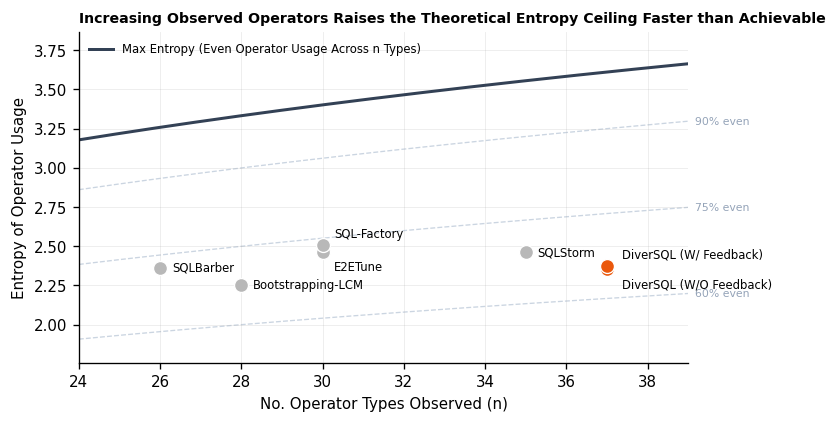

In [7]:
out_name = "entropy_tradeoff"

# the trade-off, visualised directly in entropy: the ln(K) ceiling is what
# achieved H would need to track to hold a constant "evenness" as vocabulary
# widens. Unlike the old evenness-vs-K plot, N1=exp(H) iso-lines would be flat
# here (N1 depends only on H, not K) -- the ln(K) ceiling is the entropy-native
# replacement that still shows the trend: it rises with K, achieved H mostly
# doesn't, so every workload falls further behind its own ceiling as K grows.
_K_obs = df.loc[ROWS, "n_operator_types_observed"].astype(float)
_EV_obs = df.loc[ROWS, "operator_type_entropy"].astype(float)
_H_obs = _EV_obs * np.log(_K_obs)
_k_lo, _k_hi = max(2, _K_obs.min() - 2), _K_obs.max() + 2

fig, ax = plt.subplots(figsize=(6.6, 3.6))
_k = np.linspace(_k_lo, _k_hi, 200)

ax.plot(_k, np.log(_k), color="#334155", lw=1.8, zorder=2,
        label="Max Entropy (Even Operator Usage Across n Types)")

# faint fixed-evenness reference fans -- context only, not the headline number
for frac in (0.9, 0.75, 0.6):
    ax.plot(_k, frac*np.log(_k), color="#cbd5e1", lw=0.8, ls="--", zorder=1)
    ax.text(_k_hi, frac*np.log(_k_hi), f"  {frac:.0%} even", fontsize=6.5, color="#94a3b8", va="center")

# a few points sit almost on top of each other (SQL-Factory/E2ETune at K=30;
# the two "Ours" variants at K=37) -- default same-side labels collide into
# unreadable overlap, so nudge those explicitly rather than let matplotlib guess.
LABEL_OFFSET = {
    "sql_factory_1000_tokens_tpcds": (7, 7),
    "e2etune_1000_tokens_tpcds": (7, -9),
    "gpt_generated_1000_tpcds_tokens": (9, 7),
    "gpt_generated_1000_tpcds_tokens_no_feedback": (9, -9),
}
for w in ROWS:
    if PRETTY[w] == "TPC-DS (1000)":
        continue
    k, h = float(_K_obs[w]), float(_H_obs[w])
    ax.scatter(k, h, color=COL[w], s=70, edgecolor="white", lw=0.8, zorder=3)
    dx, dy = LABEL_OFFSET.get(w, (7, 0))
    ax.annotate(PRETTY[w], (k, h), fontsize=7, xytext=(dx, dy), textcoords="offset points", va="center")

ax.set_xlim(_k_lo, _k_hi)
# zoomed to the observed H range (+ enough headroom for the ceiling's rise to
# read as a trend), not all the way to 0 -- matches the same "zoom to the
# observed range" choice made for the K-axis, for the same reason: a few
# points, so padding out to a true origin just compresses them into a corner.
_y_lo = min(float(_H_obs.min()), 0.6*np.log(_k_lo)) - 0.15
ax.set_ylim(_y_lo, np.log(_k_hi) + 0.2)
ax.set_xlabel("No. Operator Types Observed (n)"); ax.set_ylabel("Entropy of Operator Usage")
ax.set_title("Increasing Observed Operators Raises the Theoretical Entropy Ceiling Faster than Achievable",
             loc="left", fontsize=8.5, fontweight="bold")
ax.legend(fontsize=7, loc="upper left", frameon=False)
ax.grid(alpha=0.25); plt.tight_layout(); plt.show()

out_dir = FIGURES_DIR
out_dir.mkdir(parents=True, exist_ok=True)
out_png = out_dir / f"{out_name}.png"
out_pdf = out_dir / f"{out_name}.pdf"
fig.savefig(out_png)
fig.savefig(out_pdf)

## 5 · LaTeX export

Generates `booktabs`-style LaTeX for Tables 1–3 (and the §4 evenness table) directly
from the DataFrames built above, so the paper always matches what's on screen. Best
value per column is bolded (excluding the reference row, which is context not a
competitor); `--` marks NaN. Each table is wrapped in `\resizebox{\linewidth}{!}{...}`
so it always fits the column/page width regardless of how many metrics it holds.
Column headers may span two lines (`headers=...`, with `\n` marking the break) so a
long metric name wraps instead of forcing every column wider under `\resizebox`.
Requires `\usepackage{booktabs}`, `\usepackage{graphicx}` and `\usepackage{makecell}`
in the preamble.

In [8]:
_LATEX_SPECIAL = {"%": r"\%", "&": r"\&", "_": r"\_", "#": r"\#"}
def _tex_escape(s):
    for ch, esc in _LATEX_SPECIAL.items():
        s = s.replace(ch, esc)
    return s

def _tex_header(s):
    """Escape a header label, honouring '\\n' as a line break within the cell.

    A single-line label is escaped and emitted as-is. A label containing '\\n'
    is wrapped in \\makecell{...} (each line escaped, joined with \\\\) so a
    long metric name wraps onto two lines instead of forcing the whole table
    wider -- this is what keeps \\resizebox from squeezing every column down
    to fit one long header. Requires \\usepackage{makecell}.
    """
    lines = s.split("\n")
    if len(lines) == 1:
        return _tex_escape(lines[0])
    return r"\makecell{" + r" \\ ".join(_tex_escape(line) for line in lines) + "}"

def to_latex(tbl, fmts, caption, label, higher_is_better=True, ref=REF, ours=OURS, headers=None, highlight_best=True,
             placement="t", vspace=None):
    """Render `tbl` (index = raw workload keys) as a booktabs LaTeX table.

    fmts: {column -> format spec}, e.g. "{:.3f}", "{:.0f}", "{:.1%}". Keys
    must match `tbl`'s actual column names, since they're also used to index
    into `tbl`.
    headers: optional {column -> display label}, for when the printed header
    should differ from the column name (e.g. a shorter label, or one broken
    across two lines with '\\n' to keep the table narrow). Falls back to the
    column name itself when a column has no entry.
    placement: float specifier for \\begin{table}[...] (default "t").
    vspace: optional length (e.g. "-1em") emitted as \\vspace{...} right after the caption.
    highlight_best: False turns off the bold+underline on best-in-column values
    (for tables where "best" is not a meaningful claim); higher_is_better is then unused.
    higher_is_better: True/False, or a dict per-column, controlling which value
    is bolded (best among non-reference rows; ties all bold, unless *every*
    competitor ties -- then nothing is bolded, since there's no winner to flag).
    Reference row is never bolded. Row order follows `tbl.index` as given
    (reference, then baselines, then ours last). Only the reference block gets
    its own \\midrule; ours sits directly below the baselines with no rule
    between them. Column headers, caption and cell values all get LaTeX special
    characters (%, &, _, #) escaped, so raw names like "Validity %" don't
    silently truncate the row via an unescaped comment character. The tabular
    is wrapped in \\resizebox{\\linewidth}{!}{...} so it always fits the page
    width regardless of column count (requires \\usepackage{graphicx}).
    """
    cols = list(fmts.keys())
    headers = headers or {}
    hib = higher_is_better if isinstance(higher_is_better, dict) else {c: higher_is_better for c in cols}

    # best value per column, over non-reference rows only (need >=2 to compare);
    # ties are resolved on the *formatted* string so e.g. 0.9996 and 1.000 that
    # both display as "1.000" both get bolded, not just whichever sorts first.
    # If every competitor ties on that formatted value, there's no winner to
    # highlight, so skip bolding the column entirely.
    competitors = [w for w in tbl.index if w != ref]
    best_disp = {}
    for c in cols:
        vals = tbl.loc[competitors, c].astype(float)
        notna = vals.dropna()
        if len(notna) >= 2:
            best_val = notna.max() if hib.get(c, True) else notna.min()
            disp = fmts[c].format(best_val)
            if any(fmts[c].format(v) != disp for v in notna):
                best_disp[c] = disp

    def fmt_cell(w, c):
        v = tbl.loc[w, c]
        if pd.isna(v):
            return "--"
        s = fmts[c].format(float(v))
        is_best = highlight_best and w != ref and best_disp.get(c) == s
        s = _tex_escape(s)
        if is_best:
            s = r"\underline{\textbf{" + s + "}}"
        return s

    colspec = "l" + "c" * len(cols)
    body = [
        r"\begin{tabular}{" + colspec + "}",
        r"\toprule",
        "Workload & " + " & ".join(_tex_header(headers.get(c, c)) for c in cols) + r" \\",
        r"\midrule",
    ]
    for w in tbl.index:
        name = PRETTY.get(w, w)
        if w == ref:
            name = r"\textit{" + name + "}"
        elif w in ours:
            name = r"\textbf{" + name + "}"
        row = " & ".join(fmt_cell(w, c) for c in cols)
        body.append(f"{name} & {row} " + r"\\")
        if w == ref:
            body.append(r"\midrule")
    body += [r"\bottomrule", r"\end{tabular}"]

    lines = [
        r"\begin{table}[" + placement + "]",
        r"\centering",
        r"\caption{" + _tex_escape(caption) + "}",
        *([r"\vspace{" + vspace + "}"] if vspace else []),
        r"\label{" + label + "}",
        r"\resizebox{\linewidth}{!}{%",
        *body,
        r"}",
        r"\end{table}",
    ]
    return "\n".join(lines)


In [9]:
print(to_latex(
    table1,
    {"Operator types": "{:.0f}", "Operator cov. (K/|U|)": "{:.2f}",
     "Unique plan-graph ratio": "{:.3f}", "Mean NN distance": "{:.3f}",
     "Plan-graph Vendi": "{:.1f}", "Vendi (cosine)": "{:.1f}"},
    headers={"Operator types": "Operator\ncount",
             "Operator cov. (K/|U|)": "Operator\ncoverage",
             "Unique plan-graph ratio": "Unique plan-\ngraph ratio",
             "Mean NN distance": "Mean NN\ndistance",
             "Plan-graph Vendi": "Vendi\n($\\kappa$)",
             "Vendi (cosine)": "Vendi\n(cosine)"},
    caption="Structural diversity of compiled plans.",
    label="tab:structural-diversity",
    placement="h!",
    vspace="-1em",
))


\begin{table}[h!]
\centering
\caption{Structural diversity of compiled plans.}
\vspace{-1em}
\label{tab:structural-diversity}
\resizebox{\linewidth}{!}{%
\begin{tabular}{lcccccc}
\toprule
Workload & \makecell{Operator \\ count} & \makecell{Operator \\ coverage} & \makecell{Unique plan- \\ graph ratio} & \makecell{Mean NN \\ distance} & \makecell{Vendi \\ ($\kappa$)} & \makecell{Vendi \\ (cosine)} \\
\midrule
\textit{TPC-DS (1000)} & 28 & 0.49 & 0.075 & 0.000 & 22.7 & 7.7 \\
\midrule
Bootstrapping-LCM & 28 & 0.49 & 0.916 & 0.138 & 19.0 & 7.0 \\
E2ETune & 30 & 0.53 & 0.976 & 0.245 & 55.3 & 11.3 \\
SQL-Factory & 30 & 0.53 & 0.965 & 0.219 & 52.4 & 9.6 \\
SQLBarber & 26 & 0.46 & 0.108 & 0.002 & 16.4 & 3.4 \\
SQLStorm & 35 & 0.61 & 0.790 & 0.270 & 77.6 & 9.9 \\
\textbf{DiverSQL (W/O Feedback)} & \underline{\textbf{37}} & \underline{\textbf{0.65}} & \underline{\textbf{1.000}} & 0.325 & 87.1 & 13.0 \\
\textbf{DiverSQL (W/ Feedback)} & \underline{\textbf{37}} & \underline{\textbf{0.65}} & \unde

In [10]:
print(to_latex(
    table2,
    {"Table cov.": "{:.3f}", "Column cov.": "{:.3f}",
     "Join-edge cov.": "{:.3f}", "Unique table-set ratio": "{:.3f}"},
    headers={"Table cov.":"Table\ncoverage.",
             "Column cov.": "Column\ncoverage.",
             "Join-edge cov.": "Join-edge\ncoverage.",
             "Unique table-set ratio": "Unique table\n-set ratio"},
    caption="Schema diversity: coverage and table-combination breadth on TPC-DS.",
    label="tab:schema-diversity",
))


\begin{table}[t]
\centering
\caption{Schema diversity: coverage and table-combination breadth on TPC-DS.}
\label{tab:schema-diversity}
\resizebox{\linewidth}{!}{%
\begin{tabular}{lcccc}
\toprule
Workload & \makecell{Table \\ coverage.} & \makecell{Column \\ coverage.} & \makecell{Join-edge \\ coverage.} & \makecell{Unique table \\ -set ratio} \\
\midrule
\textit{TPC-DS (1000)} & 1.000 & 0.614 & 0.683 & 0.054 \\
\midrule
Bootstrapping-LCM & 1.000 & 0.800 & \underline{\textbf{1.000}} & 0.394 \\
E2ETune & 1.000 & 0.904 & \underline{\textbf{1.000}} & 0.882 \\
SQL-Factory & 1.000 & 0.805 & 0.988 & 0.382 \\
SQLBarber & 1.000 & 0.593 & 0.963 & 0.122 \\
SQLStorm & 1.000 & 0.744 & 0.768 & 0.397 \\
\textbf{DiverSQL (W/O Feedback)} & 1.000 & 0.974 & \underline{\textbf{1.000}} & \underline{\textbf{0.948}} \\
\textbf{DiverSQL (W/ Feedback)} & 1.000 & \underline{\textbf{0.979}} & \underline{\textbf{1.000}} & 0.932 \\
\bottomrule
\end{tabular}
}
\end{table}


In [11]:
print(to_latex(
    table3,
    {"Tokens / query": "{:,.0f}",
     "Input tok / query": "{:,.0f}", "Output tok / query": "{:,.0f}",
     "Reasoning tok / query": "{:,.0f}", "LLM calls / query": "{:.2f}",
     "Gen. time (min)": "{:.1f}", "Sec / query": "{:.1f}",
     "Queries / min": "{:.2f}"},
    headers={"Tokens / query": "Tokens /\nquery",
             "Input tok / query": "Input tokens\n/ query", "Output tok / query": "Output tokens\n/ query",
             "Reasoning tok / query": "Reasoning\n tokens / query", "LLM calls / query": "LLM calls\n/ query",
             "Gen. time (min)": "Gen. time\n(min)", "Sec / query": "Sec /\nquery",
             "Queries / min": "Queries\n/ min"},
    caption="Query quality and generation overhead on TPC-DS.",
    label="tab:quality-overhead",
    highlight_best=False,
    higher_is_better={"Tokens / query": False,
                       "Input tok / query": False, "Output tok / query": False,
                       "Reasoning tok / query": False, "LLM calls / query": False,
                       "Gen. time (min)": False, "Sec / query": False,
                       "Queries / min": True},
))

\begin{table}[t]
\centering
\caption{Query quality and generation overhead on TPC-DS.}
\label{tab:quality-overhead}
\resizebox{\linewidth}{!}{%
\begin{tabular}{lcccccccc}
\toprule
Workload & \makecell{Tokens / \\ query} & \makecell{Input tokens \\ / query} & \makecell{Output tokens \\ / query} & \makecell{Reasoning \\  tokens / query} & \makecell{LLM calls \\ / query} & \makecell{Gen. time \\ (min)} & \makecell{Sec / \\ query} & \makecell{Queries \\ / min} \\
\midrule
\textit{TPC-DS (1000)} & -- & -- & -- & -- & -- & -- & -- & -- \\
\midrule
Bootstrapping-LCM & 12,734 & 1,962 & 10,773 & 10,082 & 1.50 & 456.0 & 27.4 & 2.19 \\
E2ETune & 7,985 & 1,853 & 6,132 & 5,458 & 1.40 & 239.5 & 14.4 & 4.17 \\
SQL-Factory & 3,198 & 341 & 2,856 & 2,331 & 0.34 & 332.0 & 19.9 & 3.01 \\
SQLBarber & 1,072 & 283 & 788 & 704 & 0.45 & 193.8 & 11.6 & 5.16 \\
SQLStorm & 26,329 & 8,340 & 17,989 & 14,466 & 3.68 & 899.9 & 54.0 & 1.11 \\
\textbf{DiverSQL (W/O Feedback)} & 8,432 & 3,789 & 4,643 & 3,244 & 1.64 & 63.

In [12]:
print(to_latex(
    entropy_tbl,
    {"Operator types (K)": "{:.0f}", "Entropy H (nats)": "{:.3f}",
     "Max entropy ln(K)": "{:.3f}", "Effective # (N1)": "{:.2f}"},
    headers={"Operator types (K)": "Operator\ntypes (K)", "Entropy H (nats)": "Entropy H\n(nats)",
             "Max entropy ln(K)": "Max entropy\nln(K)", "Effective # (N1)": "Effective #\n(N1)"},
    caption="Operator-usage entropy vs. its own ceiling. Entropy H is reported "
            "directly (nats); ln(K) is the entropy achievable if the K observed "
            "operator types were used exactly equally often. The gap H - ln(K) "
            "widens as K grows -- a wider operator vocabulary gets harder to use "
            "evenly, not easier. N1 = exp(H) is the effective number of equally-"
            "used operator types at the same entropy.",
    label="tab:entropy-ceiling",
    higher_is_better={"Operator types (K)": True, "Entropy H (nats)": True,
                       "Max entropy ln(K)": True, "Effective # (N1)": True},
))


\begin{table}[t]
\centering
\caption{Operator-usage entropy vs. its own ceiling. Entropy H is reported directly (nats); ln(K) is the entropy achievable if the K observed operator types were used exactly equally often. The gap H - ln(K) widens as K grows -- a wider operator vocabulary gets harder to use evenly, not easier. N1 = exp(H) is the effective number of equally-used operator types at the same entropy.}
\label{tab:entropy-ceiling}
\resizebox{\linewidth}{!}{%
\begin{tabular}{lcccc}
\toprule
Workload & \makecell{Operator \\ types (K)} & \makecell{Entropy H \\ (nats)} & \makecell{Max entropy \\ ln(K)} & \makecell{Effective \# \\ (N1)} \\
\midrule
\textit{TPC-DS (1000)} & 28 & 2.295 & 3.332 & 9.93 \\
\midrule
Bootstrapping-LCM & 28 & 2.253 & 3.332 & 9.51 \\
E2ETune & 30 & 2.461 & 3.401 & 11.71 \\
SQL-Factory & 30 & \underline{\textbf{2.505}} & 3.401 & \underline{\textbf{12.24}} \\
SQLBarber & 26 & 2.363 & 3.258 & 10.62 \\
SQLStorm & 35 & 2.462 & 3.555 & 11.73 \\
\textbf{DiverSQL (W/O